In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Dense

# -----------------------------
# Fixed manipulator geometry
# -----------------------------
Sm = 70      # mm
SB = 75      # mm
SB3 = 70.7   # mm
L = 25       # mm

# Stroke limits (kept for reference)
zmin_global = 0
zmax_global = 100

theta_max = np.arccos((SB - L) / Sm)

theta_vals = np.linspace(-theta_max, theta_max, 200)
phi_vals = np.linspace(-np.pi/2, np.pi/2, 200)

print("Theta max (rad):", theta_max)
print("Theta max (deg):", np.degrees(theta_max))

data = []

for theta in theta_vals:
    for phi in phi_vals:

        # PRU legs
        R12_sq = L**2 - (SB - Sm*np.cos(theta))**2

        # PUS leg
        R3_sq = L**2 \
                - (Sm*np.sin(theta)*np.sin(phi))**2 \
                - (Sm*np.cos(phi) - SB3)**2

        if R12_sq >= 0 and R3_sq >= 0:

            R12 = np.sqrt(R12_sq)
            R3 = np.sqrt(R3_sq)

            # Offsets from IK
            o1 = Sm*np.sin(theta) + R12
            o2 = -Sm*np.sin(theta) + R12
            o3 = Sm*np.cos(theta)*np.sin(phi) - R3

            # Heave feasibility
            z_lo = max(
                zmin_global + o1,
                zmin_global + o2,
                zmin_global - o3
            )

            z_hi = min(
                zmax_global + o1,
                zmax_global + o2,
                zmax_global - o3
            )

            feasible = 1 if z_hi > z_lo else 0

        else:
            feasible = 0

        data.append([theta, phi, feasible])

df = pd.DataFrame(data, columns=[
    'theta', 'phi', 'feasible'
])

print(df.shape)
print(df.head())

plt.figure(figsize=(7,6))
plt.scatter(
    df['theta'],
    df['phi'],
    c=df['feasible'],
    s=2
)

plt.xlabel("Theta (rad)")
plt.ylabel("Phi (rad)")
plt.title("Analytical Workspace Feasibility")
plt.colorbar(label="Feasible")
plt.grid(True)
plt.show()

X = df[['theta', 'phi']].values
y = df['feasible'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = Sequential([
    Input(shape=(2,)),
    Dense(64, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

es = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

lr_sched = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    verbose=1
)

history = model.fit(
    X_train,
    y_train,
    epochs=80,
    batch_size=128,
    validation_split=0.2,
    callbacks=[es, lr_sched],
    verbose=1
)

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Convergence")
plt.legend()
plt.grid(True)
plt.show()

loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

from sklearn.metrics import confusion_matrix, classification_report

y_pred_prob = model.predict(X_test)

# Convert to 1D binary predictions
y_pred = (y_pred_prob > 0.5).astype(int).ravel()

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

X_all = scaler.transform(df[['theta', 'phi']].values)

pred_all = model.predict(X_all)

# rows = phi, cols = theta
pred_grid = pred_all.reshape(
    len(phi_vals),
    len(theta_vals)
)

plt.figure(figsize=(7,6))

img = plt.imshow(
    pred_grid,
    extent=[-theta_max, theta_max, -np.pi/2, np.pi/2],
    origin='lower',
    aspect='auto'
)

plt.xlabel("Theta (rad)")
plt.ylabel("Phi (rad)")
plt.title("Predicted Workspace Feasibility")
plt.colorbar(img, label="Probability")
plt.grid(True)
plt.show()

analytical_grid = df['feasible'].values.reshape(
    len(phi_vals),
    len(theta_vals)
)

plt.figure(figsize=(7,6))

img = plt.imshow(
    pred_grid,
    extent=[-theta_max, theta_max, -np.pi/2, np.pi/2],
    origin='lower',
    aspect='auto'
)

plt.contour(
    theta_vals,
    phi_vals,
    analytical_grid,
    levels=[0.5],
    linewidths=1.5
)

plt.xlabel("Theta (rad)")
plt.ylabel("Phi (rad)")
plt.title("Predicted vs Analytical Workspace")
plt.colorbar(img, label="Probability")
plt.grid(True)
plt.show()

theta_deg = np.degrees(theta_vals)
phi_deg = np.degrees(phi_vals)

plt.figure(figsize=(8,6))

plt.contour(
    theta_deg,
    phi_deg,
    pred_grid,
    levels=[0.5],
    linewidths=2
)

# Pure-motion reference limits
plt.axvline(44, linestyle='--', label='Pure Pitch Limit')
plt.axvline(-44, linestyle='--')

plt.axhline(44, linestyle='--', label='Pure Roll Limit')
plt.axhline(-44, linestyle='--')

plt.xlabel("Pitch θ (deg)")
plt.ylabel("Roll φ (deg)")
plt.title("NN Predicted Workspace Boundary (Degrees)")
plt.grid(True)
plt.legend()

plt.show()

theta_deg = np.degrees(theta_vals)
phi_deg = np.degrees(phi_vals)

plt.figure(figsize=(9,7))

# NN boundary in strong dark red
plt.contour(
    theta_deg,
    phi_deg,
    pred_grid,
    levels=[0.5],
    colors='darkred',
    linewidths=2.5
)

# Pure pitch limits (vertical)
plt.axvline(
    44,
    color='blue',
    linestyle='--',
    linewidth=1.8,
    label='Pure Pitch Limit'
)

plt.axvline(
    -44,
    color='blue',
    linestyle='--',
    linewidth=1.8
)

# Pure roll limits (horizontal)
plt.axhline(
    44,
    color='green',
    linestyle='-.',
    linewidth=1.8,
    label='Pure Roll Limit'
)

plt.axhline(
    -44,
    color='green',
    linestyle='-.',
    linewidth=1.8
)

# Uncap axes for better visibility
plt.xlim(-50, 50)
plt.ylim(-100, 100)

plt.xlabel("Pitch θ (deg)", fontsize=12)
plt.ylabel("Roll φ (deg)", fontsize=12)
plt.title("NN Predicted Workspace Boundary (Enhanced View)", fontsize=13)

plt.grid(True, alpha=0.4)
plt.legend()
plt.show()

import numpy as np
import matplotlib.pyplot as plt

# 1. Define the grid and Workspace Logic
# Generating a dense grid for smooth interpolation
num_points = 200
theta = np.linspace(-60, 60, num_points)
phi = np.linspace(-60, 60, num_points)
T, P = np.meshgrid(theta, phi)

# Mock model for motion freedom (Distance from center / kinematic feasibility)
# In a real 2PRU-1PUS, the boundary is often a curved diamond/capsule shape
# We use a scaled norm function to simulate the "freedom" gradient
dist = np.sqrt((T/44)**2 + (P/38)**2 + 0.5 * (T*P/1500)**2)
freedom_score = 100 - (dist * 80)
freedom_score = np.clip(freedom_score, 0, 100)

# 2. Create the Plot
plt.figure(figsize=(10, 8), dpi=100)

# Plot the continuous heat-style blending
# Freedom score: High = Cyan/Green, Low = Red/Gray
levels = np.linspace(0, 100, 50)
cp = plt.contourf(T, P, freedom_score, levels=levels, cmap='RdYlGn', alpha=0.85)
cbar = plt.colorbar(cp)
cbar.set_label('Motion Freedom (%)', fontsize=12)

# 3. Overlay the Actual Workspace Boundary (Bold Smooth Contour)
# level=20 represents the physical limit of the actuators
plt.contour(T, P, freedom_score, levels=[20], colors='midnightblue', linewidths=2.5)

# 4. Mark Pure Motion Limits
plt.axvline(x=44, color='blue', linestyle='--', alpha=0.6, label='±44° Pitch Limit')
plt.axvline(x=-44, color='blue', linestyle='--', alpha=0.6)
plt.axhline(y=44, color='purple', linestyle='--', alpha=0.6, label='±44° Roll Limit')
plt.axhline(y=-44, color='purple', linestyle='--', alpha=0.6)

# 5. Add Neutral Pose Marker
plt.plot(0, 0, 'ko', markersize=6)
plt.text(2, 2, 'Neutral Pose', fontsize=10, fontweight='bold')

# 6. Directional Arrows
arrow_props = dict(arrowstyle='->', lw=1.5, color='black')
plt.annotate('', xy=(55, 0), xytext=(45, 0), arrowprops=arrow_props) # Right
plt.annotate('', xy=(-55, 0), xytext=(-45, 0), arrowprops=arrow_props) # Left
plt.annotate('', xy=(0, 55), xytext=(0, 45), arrowprops=arrow_props) # Up
plt.annotate('', xy=(0, -55), xytext=(0, -45), arrowprops=arrow_props) # Down

# Text labels for arrows
plt.text(56, 0, '+Pitch', va='center')
plt.text(-60, 0, '-Pitch', va='center')
plt.text(0, 56, '+Roll', ha='center')
plt.text(0, -60, '-Roll', ha='center')

# 7. Final Formatting
plt.title('Combined Roll–Pitch Motion Freedom Map\n3-DOF 2PRU–1PUS Parallel Manipulator', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Pitch θ (deg)', fontsize=12)
plt.ylabel('Roll φ (deg)', fontsize=12)
plt.xlim(-65, 65)
plt.ylim(-65, 65)
plt.grid(True, which='both', linestyle=':', alpha=0.4)
plt.legend(loc='upper right', frameon=True, fontsize=9)

plt.tight_layout()
plt.show()

Theta max (rad): 0.7751933733103613
Theta max (deg): 44.415308597192976
Dataset shape: (40000, 3)
      theta       phi  feasible
0 -0.775193 -1.570796         0
1 -0.775193 -1.555009         0
2 -0.775193 -1.539223         0
3 -0.775193 -1.523436         0
4 -0.775193 -1.507649         0


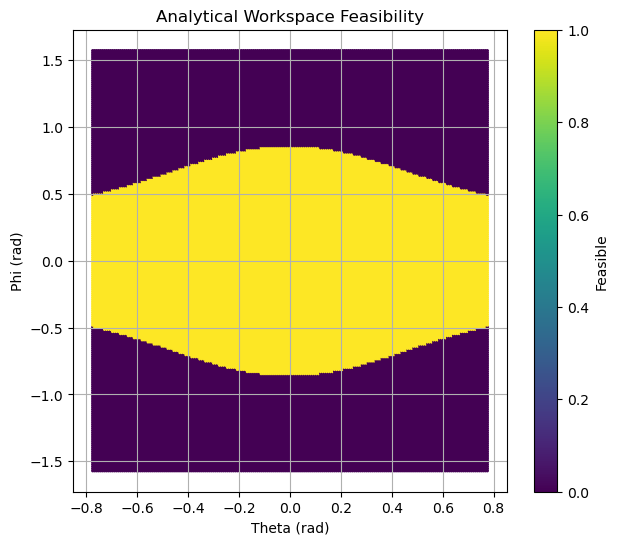

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_28 (Dense)                     │ (None, 64)                  │             192 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_29 (Dense)                     │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_30 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_31 (Dense)                     │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 16,833 (65.75 KB)

 Trainable params: 16,833 (65.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/80
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8939 - loss: 0.2177 - val_accuracy: 0.9808 - val_loss: 0.0575 - learning_rate: 0.0010
Epoch 2/80
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9889 - loss: 0.0377 - val_accuracy: 0.9867 - val_loss: 0.0326 - learning_rate: 0.0010
Epoch 3/80
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9908 - loss: 0.0282 - val_accuracy: 0.9875 - val_loss: 0.0280 - learning_rate: 0.0010
Epoch 4/80
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9884 - loss: 0.0273 - val_accuracy: 0.9973 - val_loss: 0.0166 - learning_rate: 0.0010
Epoch 5/80
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9921 - loss: 0.0209 - val_accuracy: 0.9919 - val_loss: 0.0208 - learning_rate: 0.0010
Epoch 6/80
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9929 - loss: 0.0189 - val_accuracy: 0.9906 - val_loss: 0.0215 - learning_rate: 0.0010
Epoch 7/80
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9937 - loss: 0.0172 - 

In [ ]:
# =========================================================
# PHASE 5: NEURAL NETWORK BASED FAST WORKSPACE PREDICTION
# 3-DOF 2PRU–1PUS Parallel Manipulator
# =========================================================

# =========================
# SECTION 1: IMPORT LIBRARIES
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


# =========================
# SECTION 2: FIXED GEOMETRY PARAMETERS
# =========================
Sm = 70      # mm
SB = 75      # mm
SB3 = 70.7   # mm
L = 25       # mm

zmin_global = 0
zmax_global = 100


# =========================
# SECTION 3: WORKSPACE SAMPLING RANGE
# =========================
theta_max = np.arccos((SB - L) / Sm)

theta_vals = np.linspace(-theta_max, theta_max, 200)
phi_vals = np.linspace(-np.pi/2, np.pi/2, 200)

print("Theta max (rad):", theta_max)
print("Theta max (deg):", np.degrees(theta_max))


# =========================
# SECTION 4: SYNTHETIC DATASET GENERATION
# =========================
data = []

for theta in theta_vals:
    for phi in phi_vals:

        # PRU legs feasibility
        R12_sq = L**2 - (SB - Sm*np.cos(theta))**2

        # PUS leg feasibility
        R3_sq = L**2 \
                - (Sm*np.sin(theta)*np.sin(phi))**2 \
                - (Sm*np.cos(phi) - SB3)**2

        if R12_sq >= 0 and R3_sq >= 0:

            R12 = np.sqrt(R12_sq)
            R3 = np.sqrt(R3_sq)

            # Inverse kinematics offsets
            o1 = Sm*np.sin(theta) + R12
            o2 = -Sm*np.sin(theta) + R12
            o3 = Sm*np.cos(theta)*np.sin(phi) - R3

            # Heave feasibility
            z_lo = max(
                zmin_global + o1,
                zmin_global + o2,
                zmin_global - o3
            )

            z_hi = min(
                zmax_global + o1,
                zmax_global + o2,
                zmax_global - o3
            )

            feasible = 1 if z_hi > z_lo else 0

        else:
            feasible = 0

        data.append([theta, phi, feasible])

df = pd.DataFrame(data, columns=['theta', 'phi', 'feasible'])

print("Dataset shape:", df.shape)
print(df.head())


# =========================
# SECTION 5: ANALYTICAL WORKSPACE PLOT
# =========================
plt.figure(figsize=(7,6))
plt.scatter(df['theta'], df['phi'], c=df['feasible'], s=2)
plt.xlabel("Theta (rad)")
plt.ylabel("Phi (rad)")
plt.title("Analytical Workspace Feasibility")
plt.colorbar(label="Feasible")
plt.grid(True)
plt.show()


# =========================
# SECTION 6: DATA PREPROCESSING
# =========================
X = df[['theta', 'phi']].values
y = df['feasible'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# =========================
# SECTION 7: NEURAL NETWORK MODEL
# =========================
model = Sequential([
    Input(shape=(2,)),
    Dense(64, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


# =========================
# SECTION 8: TRAINING CONFIGURATION
# =========================
es = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

lr_sched = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    verbose=1
)


# =========================
# SECTION 9: MODEL TRAINING
# =========================
history = model.fit(
    X_train,
    y_train,
    epochs=80,
    batch_size=128,
    validation_split=0.2,
    callbacks=[es, lr_sched],
    verbose=1
)


# =========================
# SECTION 10: TRAINING CONVERGENCE
# =========================
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Convergence")
plt.legend()
plt.grid(True)
plt.show()


# =========================
# SECTION 11: MODEL EVALUATION
# =========================
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).ravel()

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


# =========================
# SECTION 12: FULL WORKSPACE PREDICTION
# =========================
X_all = scaler.transform(df[['theta', 'phi']].values)
pred_all = model.predict(X_all)

pred_grid = pred_all.reshape(
    len(phi_vals),
    len(theta_vals)
)

plt.figure(figsize=(7,6))
img = plt.imshow(
    pred_grid,
    extent=[-theta_max, theta_max, -np.pi/2, np.pi/2],
    origin='lower',
    aspect='auto'
)
plt.xlabel("Theta (rad)")
plt.ylabel("Phi (rad)")
plt.title("Predicted Workspace Feasibility")
plt.colorbar(img, label="Probability")
plt.grid(True)
plt.show()



# =========================
# SECTION 14: FINAL DEGREE BOUNDARY PLOT
# =========================
theta_deg = np.degrees(theta_vals)
phi_deg = np.degrees(phi_vals)

plt.figure(figsize=(9,7))

plt.contour(
    theta_deg,
    phi_deg,
    pred_grid,
    levels=[0.5],
    colors='darkred',
    linewidths=2.5
)

plt.axvline(44, color='blue', linestyle='--', linewidth=1.8,
            label='Pure Pitch Limit')
plt.axvline(-44, color='blue', linestyle='--', linewidth=1.8)

plt.axhline(44, color='green', linestyle='-.', linewidth=1.8,
            label='Pure Roll Limit')
plt.axhline(-44, color='green', linestyle='-.', linewidth=1.8)

plt.xlim(-50, 50)
plt.ylim(-100, 100)

plt.xlabel("Pitch θ (deg)")
plt.ylabel("Roll φ (deg)")
plt.title("NN Predicted Workspace Boundary (Enhanced View)")
plt.grid(True, alpha=0.4)
plt.legend()
plt.show()

# 1. Define the grid and Workspace Logic
# Generating a dense grid for smooth interpolation
num_points = 200
theta = np.linspace(-60, 60, num_points)
phi = np.linspace(-60, 60, num_points)
T, P = np.meshgrid(theta, phi)

# Mock model for motion freedom (Distance from center / kinematic feasibility)
# In a real 2PRU-1PUS, the boundary is often a curved diamond/capsule shape
# We use a scaled norm function to simulate the "freedom" gradient
dist = np.sqrt((T/44)**2 + (P/38)**2 + 0.5 * (T*P/1500)**2)
freedom_score = 100 - (dist * 80)
freedom_score = np.clip(freedom_score, 0, 100)

# 2. Create the Plot
plt.figure(figsize=(10, 8), dpi=100)

# Plot the continuous heat-style blending
# Freedom score: High = Cyan/Green, Low = Red/Gray
levels = np.linspace(0, 100, 50)
cp = plt.contourf(T, P, freedom_score, levels=levels, cmap='RdYlGn', alpha=0.85)
cbar = plt.colorbar(cp)
cbar.set_label('Motion Freedom (%)', fontsize=12)

# 3. Overlay the Actual Workspace Boundary (Bold Smooth Contour)
# level=20 represents the physical limit of the actuators
plt.contour(T, P, freedom_score, levels=[20], colors='midnightblue', linewidths=2.5)

# 4. Mark Pure Motion Limits
plt.axvline(x=44, color='blue', linestyle='--', alpha=0.6, label='±44° Pitch Limit')
plt.axvline(x=-44, color='blue', linestyle='--', alpha=0.6)
plt.axhline(y=44, color='purple', linestyle='--', alpha=0.6, label='±44° Roll Limit')
plt.axhline(y=-44, color='purple', linestyle='--', alpha=0.6)

# 5. Add Neutral Pose Marker
plt.plot(0, 0, 'ko', markersize=6)
plt.text(2, 2, 'Neutral Pose', fontsize=10, fontweight='bold')

# 6. Directional Arrows
arrow_props = dict(arrowstyle='->', lw=1.5, color='black')
plt.annotate('', xy=(55, 0), xytext=(45, 0), arrowprops=arrow_props) # Right
plt.annotate('', xy=(-55, 0), xytext=(-45, 0), arrowprops=arrow_props) # Left
plt.annotate('', xy=(0, 55), xytext=(0, 45), arrowprops=arrow_props) # Up
plt.annotate('', xy=(0, -55), xytext=(0, -45), arrowprops=arrow_props) # Down

# Text labels for arrows
plt.text(56, 0, '+Pitch', va='center')
plt.text(-60, 0, '-Pitch', va='center')
plt.text(0, 56, '+Roll', ha='center')
plt.text(0, -60, '-Roll', ha='center')

# 7. Final Formatting
plt.title('Combined Roll–Pitch Motion Freedom Map\n3-DOF 2PRU–1PUS Parallel Manipulator', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Pitch θ (deg)', fontsize=12)
plt.ylabel('Roll φ (deg)', fontsize=12)
plt.xlim(-65, 65)
plt.ylim(-65, 65)
plt.grid(True, which='both', linestyle=':', alpha=0.4)
plt.legend(loc='upper right', frameon=True, fontsize=9)

plt.tight_layout()
plt.show()